Zadanie 6

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


In [119]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


sum               21.00
count             29.00
Survival_Ratio    72.41
Name: 4, dtype: float64

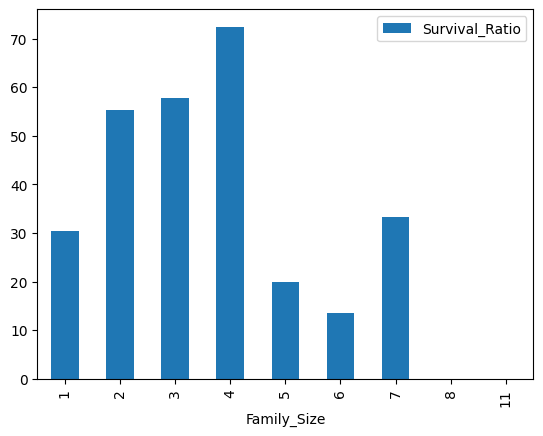

In [120]:
titanic['Family_Size'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic_family_survival = titanic.groupby(['Family_Size'])['Survived'].agg(['sum','count'])
titanic_family_survival['Survival_Ratio'] = round(titanic_family_survival['sum'] / titanic_family_survival['count'] * 100, 2)
titanic_family_survival[['Survival_Ratio']].plot(kind='bar')
titanic_family_survival.loc[titanic_family_survival['Survival_Ratio'].idxmax()]

Zadanie 7

In [121]:
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame
df_housing.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [122]:
regions_lat = np.linspace(df_housing['Latitude'].min(), df_housing['Latitude'].max(),6)
regions_lon = np.linspace(df_housing['Longitude'].min(), df_housing['Longitude'].max(),6)
regions_lat[0]  -= 0.0001
regions_lat[-1] += 0.0001
regions_lon[0]  -= 0.0001
regions_lon[-1] += 0.0001

print(regions_lat)
print(regions_lon)

df_housing['Region'] = 'Unknown'
for i in range(5):
    for j in range(5):
        df_housing.loc[
            (df_housing['Latitude']  >= regions_lat[i]) &
            (df_housing['Latitude']  <  regions_lat[i+1]) &
            (df_housing['Longitude'] >= regions_lon[j]) &
            (df_housing['Longitude'] <  regions_lon[j+1]),
            'Region'
        ] = f"{i}"

df_housing

[32.5399 34.422  36.304  38.186  40.068  41.9501]
[-124.3501 -122.342  -120.334  -118.326  -116.318  -114.3099]


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Region
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,3
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,3
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,3
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,3


In [123]:
df_region_mean = df_housing.groupby(['Region'])['MedHouseVal'].agg(['mean'])
df_region_mean

,mean
Region,
0,2.228903
1,1.403145
2,2.240963
3,1.413950
4,0.844997


Zadanie 10

In [124]:
def IQR(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    return q3 - q1

df_housing_iqr = df_housing.groupby('Region')['MedHouseVal'].agg(IQR)
df_housing_iqr


Region
0    1.27800
1    1.09700
2    1.79725
3    0.77750
4    0.31475
Name: MedHouseVal, dtype: float64